# Wind Farm Layout Optimisation with Reinforcement Learning 

This notebook presents a **Reinforcement Learning** approach to place 50 turbines sequentially:

- **State**: The current set of turbine coordinates (padded to 50).
- **Action**: Choose the next turbine location from a discrete grid of valid positions.
- **Reward**: The final AEP after all turbines are placed.
- **Algorithm**: Deep Q‑Network (DQN) – a neural network approximates Q‑values for state‑action pairs.

To accelerate training, we first build a surrogate model (neural network) that predicts AEP quickly. The DQN agent then learns to maximise the surrogate’s predicted AEP.

Finally, the best layout found during training is polished with a local hill‑climbing refinement using the true AEP evaluator.

In [1]:
# Imports and setup
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from itertools import product
import time
import random
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

from Farm_Evaluator_Vec import (
    getTurbLoc, loadPowerCurve, binWindResourceData,
    preProcessing, getAEP, checkConstraints
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Load data and define true AEP evaluator
DATA_DIR = 'Wind_Data'
combined_wind_path = "combined_wind_data_all_years.csv"

# Create combined wind file if needed
if not os.path.exists(combined_wind_path):
    wind_files = [os.path.join(DATA_DIR, f'wind_data_{y}.csv') for y in [2007,2008,2009,2013,2014,2015,2017]]
    dfs = [pd.read_csv(f) for f in wind_files]
    combined = pd.concat(dfs)
    combined['date'] = pd.to_datetime(combined['date'])
    combined.sort_values('date', inplace=True)
    combined.to_csv(combined_wind_path, index=False)

wind_inst_freq = binWindResourceData(combined_wind_path)

power_curve_df = pd.read_csv('power_curve.csv')
power_curve_arr = power_curve_df.to_numpy(dtype=np.float32)

turb_rad = 50.0   # diameter 100 m

def compute_true_aep(coords):
    """Official AEP evaluator for a list/array of coordinates."""
    if len(coords) == 0:
        return 0.0
    coords_arr = np.array(coords, dtype=np.float32)
    n_turbs = len(coords_arr)
    n_wind_inst, cos_dir, sin_dir, wind_sped_stacked, C_t = preProcessing(power_curve_arr, n_turbs)
    aep = getAEP(turb_rad, coords_arr, power_curve_arr, wind_inst_freq,
                 n_wind_inst, cos_dir, sin_dir, wind_sped_stacked, C_t)
    return aep

print("True AEP evaluator ready.")

True AEP evaluator ready.


In [3]:
# Generate training data for surrogate
def generate_random_valid_layout(n_turbs=50, min_dist=400, bounds=(50,3950)):
    coords = []
    for _ in range(n_turbs):
        for _ in range(5000):
            x = np.random.uniform(*bounds)
            y = np.random.uniform(*bounds)
            new_pt = np.array([x, y])
            if len(coords) == 0:
                coords.append(new_pt)
                break
            dists = np.linalg.norm(np.array(coords) - new_pt, axis=1)
            if np.min(dists) >= min_dist:
                coords.append(new_pt)
                break
        else:
            return generate_random_valid_layout(n_turbs, min_dist, bounds)
    return np.array(coords)

# Features: fixed-length vector from coordinates (permutation invariant)
def extract_features(coords, max_turbs=50, n_dist_bins=10):
    n = len(coords)
    feats = []
    feats.append(n / max_turbs)
    x, y = coords[:,0], coords[:,1]
    feats.extend([np.mean(x)/4000, np.std(x)/4000, np.min(x)/4000, np.max(x)/4000])
    feats.extend([np.mean(y)/4000, np.std(y)/4000, np.min(y)/4000, np.max(y)/4000])
    if n >= 2:
        dists = pdist(coords) / 4000.0
        feats.extend([np.min(dists), np.max(dists), np.mean(dists), np.std(dists)])
        hist, _ = np.histogram(dists, bins=n_dist_bins, range=(0, np.sqrt(2)))
        feats.extend(hist / n)
    else:
        feats.extend([0]*4 + [0]*n_dist_bins)
    if n >= 2:
        nn_dists = [np.min(np.linalg.norm(np.delete(coords,i,axis=0)-coords[i],axis=1)) for i in range(n)]
        nn_dists = np.array(nn_dists) / 4000.0
        feats.extend([np.min(nn_dists), np.max(nn_dists), np.mean(nn_dists), np.std(nn_dists)])
    else:
        feats.extend([0]*4)
    return np.array(feats, dtype=np.float32)

# Generate dataset
np.random.seed(42)
X, y = [], []
for _ in range(500):
    layout = generate_random_valid_layout(50)
    X.append(extract_features(layout))
    y.append(compute_true_aep(layout))
X = np.array(X)
y = np.array(y).reshape(-1,1)

# Split and scale
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)

print(f"Training samples: {len(X_train)}, Validation: {len(X_val)}")

Training samples: 400, Validation: 100


In [4]:
# Train surrogate neural network
class SurrogateNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128,128,64]):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

surrogate = SurrogateNN(X_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(surrogate.parameters(), lr=1e-3)

X_train_t = torch.tensor(X_train_sc, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val_sc, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)

batch_size = 64
dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

epochs = 200
for epoch in range(epochs):
    surrogate.train()
    for bx, by in loader:
        optimizer.zero_grad()
        loss = criterion(surrogate(bx), by)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 20 == 0:
        surrogate.eval()
        with torch.no_grad():
            val_loss = criterion(surrogate(X_val_t), y_val_t).item()
        print(f"Epoch {epoch+1}: Val Loss = {val_loss:.4f}")

# Predict function
# Cell 4 (corrected predict_aep function)
def predict_aep(coords):
    if isinstance(coords, list):
        coords = np.array(coords)
    # If empty array (no turbines), return a small default value
    if len(coords) == 0:
        return 0.0
    feats = extract_features(coords).reshape(1, -1)
    feats_sc = scaler.transform(feats)
    with torch.no_grad():
        return surrogate(torch.tensor(feats_sc, dtype=torch.float32).to(device)).item()

print("Surrogate model trained.")

Epoch 20: Val Loss = 13568.9102
Epoch 40: Val Loss = 3922.6211
Epoch 60: Val Loss = 2493.7734
Epoch 80: Val Loss = 1915.6587
Epoch 100: Val Loss = 1615.0503
Epoch 120: Val Loss = 1388.9806
Epoch 140: Val Loss = 1272.1555
Epoch 160: Val Loss = 1144.5127
Epoch 180: Val Loss = 1041.3657
Epoch 200: Val Loss = 965.4616
Surrogate model trained.


In [5]:
# Define environment
class WindFarmEnv:
    def __init__(self, candidate_grid_spacing=200):
        # Candidate grid points (feasible a priori with boundary clearance)
        self.candidates = list(product(
            np.arange(50, 3951, candidate_grid_spacing),
            np.arange(50, 3951, candidate_grid_spacing)
        ))
        self.n_candidates = len(self.candidates)
        self.max_turbs = 50
        self.min_dist = 400
        self.reset()

    def reset(self):
        self.placed = []  # list of (x,y) tuples
        return self._get_state()

   
    def _get_state(self):
        if len(self.placed) == 0:
            # Return feature vector for an empty layout (all zeros of appropriate length)
            dummy_coords = np.zeros((1, 2))
            return extract_features(dummy_coords)
        else:
            coords = np.array(self.placed)
            return extract_features(coords)

    def get_valid_actions(self):
        """Return list of candidate indices that are valid to place next."""
        valid = []
        for idx, cand in enumerate(self.candidates):
            if cand in self.placed:
                continue
            if len(self.placed) == 0:
                valid.append(idx)
            else:
                dists = [np.linalg.norm(np.array(cand) - np.array(s)) for s in self.placed]
                if min(dists) >= self.min_dist:
                    valid.append(idx)
        return valid

    def step(self, action_idx):
        """Place turbine at chosen candidate. Returns (next_state, reward, done, info)."""
        if action_idx not in self.get_valid_actions():
            # Invalid action: large negative reward and terminate
            reward = -1000.0
            done = True
            return self._get_state(), reward, done, {}
        cand = self.candidates[action_idx]
        self.placed.append(cand)
        done = (len(self.placed) == self.max_turbs)
        if done:
            reward = predict_aep(self.placed)
        else:
            reward = 0.0
        return self._get_state(), reward, done, {}

In [6]:
# DQN Network and Agent
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden_dims=[256,256,128]):
        super().__init__()
        layers = []
        prev = state_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, n_actions))
        self.net = nn.Sequential(*layers)

    def forward(self, state):
        return self.net(state)

class DQNAgent:
    def __init__(self, state_dim, n_actions, lr=1e-3, gamma=0.99,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.state_dim = state_dim
        self.n_actions = n_actions
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.q_net = QNetwork(state_dim, n_actions).to(device)
        self.target_net = QNetwork(state_dim, n_actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.memory = deque(maxlen=10000)
        self.batch_size = 64

    def act(self, state, valid_actions):
        """Epsilon‑greedy action selection among valid actions."""
        if np.random.rand() < self.epsilon:
            return np.random.choice(valid_actions)
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            q_vals = self.q_net(state_t).cpu().numpy().flatten()
        # Mask invalid actions
        masked_q = np.full_like(q_vals, -np.inf)
        masked_q[valid_actions] = q_vals[valid_actions]
        return np.argmax(masked_q)

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        batch = random.sample(self.memory, self.batch_size)
        states = torch.tensor([s for s,_,_,_,_ in batch], dtype=torch.float32).to(device)
        actions = torch.tensor([a for _,a,_,_,_ in batch], dtype=torch.long).unsqueeze(1).to(device)
        rewards = torch.tensor([r for _,_,r,_,_ in batch], dtype=torch.float32).unsqueeze(1).to(device)
        next_states = torch.tensor([ns for _,_,_,ns,_ in batch], dtype=torch.float32).to(device)
        dones = torch.tensor([d for _,_,_,_,d in batch], dtype=torch.float32).unsqueeze(1).to(device)

        q_vals = self.q_net(states).gather(1, actions)
        with torch.no_grad():
            next_q_vals = self.target_net(next_states).max(1, keepdim=True)[0]
            target = rewards + (1 - dones) * self.gamma * next_q_vals
        loss = nn.MSELoss()(q_vals, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [7]:
#  Training Loop
env = WindFarmEnv(candidate_grid_spacing=200)
state_dim = len(env.reset())
agent = DQNAgent(state_dim, env.n_candidates, lr=1e-3)

episodes = 500
target_update_freq = 10
best_layout = None
best_aep = -np.inf

for ep in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0
    while not done:
        valid_actions = env.get_valid_actions()
        action = agent.act(state, valid_actions)
        next_state, reward, done, _ = env.step(action)
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        agent.replay()
    if done and reward > best_aep:
        best_aep = reward
        best_layout = env.placed.copy()
    agent.decay_epsilon()
    if ep % target_update_freq == 0:
        agent.update_target()
    if (ep+1) % 50 == 0:
        print(f"Episode {ep+1:3d} | Epsilon: {agent.epsilon:.3f} | Reward: {total_reward:.2f} | Best: {best_aep:.2f}")

print("Training finished.")

Episode  50 | Epsilon: 0.778 | Reward: 634.36 | Best: 771.81
Episode 100 | Epsilon: 0.606 | Reward: 670.73 | Best: 799.16
Episode 150 | Epsilon: 0.471 | Reward: 571.68 | Best: 799.16
Episode 200 | Epsilon: 0.367 | Reward: 615.62 | Best: 838.44
Episode 250 | Epsilon: 0.286 | Reward: 707.72 | Best: 838.44
Episode 300 | Epsilon: 0.222 | Reward: 665.08 | Best: 838.44
Episode 350 | Epsilon: 0.173 | Reward: 632.71 | Best: 847.06
Episode 400 | Epsilon: 0.135 | Reward: 647.90 | Best: 1150.88
Episode 450 | Epsilon: 0.105 | Reward: 659.91 | Best: 1150.88
Episode 500 | Epsilon: 0.082 | Reward: 736.89 | Best: 1150.88
Training finished.


In [26]:
best_layout

[(np.int64(3050), np.int64(2650)),
 (np.int64(450), np.int64(2650)),
 (np.int64(1650), np.int64(3850)),
 (np.int64(1450), np.int64(850)),
 (np.int64(1050), np.int64(2250)),
 (np.int64(250), np.int64(3050)),
 (np.int64(2050), np.int64(850)),
 (np.int64(1650), np.int64(1250)),
 (np.int64(1050), np.int64(3850)),
 (np.int64(2050), np.int64(2450)),
 (np.int64(450), np.int64(2250)),
 (np.int64(2250), np.int64(3450)),
 (np.int64(450), np.int64(1650)),
 (np.int64(1450), np.int64(1650)),
 (np.int64(2650), np.int64(2250)),
 (np.int64(2650), np.int64(650)),
 (np.int64(3850), np.int64(450)),
 (np.int64(1650), np.int64(450)),
 (np.int64(650), np.int64(3050)),
 (np.int64(2450), np.int64(1450)),
 (np.int64(1450), np.int64(2450)),
 (np.int64(3450), np.int64(3850)),
 (np.int64(1850), np.int64(2050)),
 (np.int64(1450), np.int64(2850)),
 (np.int64(3850), np.int64(3850)),
 (np.int64(2650), np.int64(1850)),
 (np.int64(2650), np.int64(2850)),
 (np.int64(1850), np.int64(2850)),
 (np.int64(2250), np.int64(185

In [8]:
true_aep_rl = compute_true_aep(best_layout)
print(f"True AEP of best RL layout: {true_aep_rl:.4f} GWh")

# Local refinement (same as in greedy notebook)
def refine_local(coords, max_passes=3, step=20, range_=100):
    coords = list(coords)
    for _ in range(max_passes):
        improved = False
        for i in range(len(coords)):
            best_aep = compute_true_aep(coords)
            best_coord = coords[i]
            x0, y0 = coords[i]
            for dx in range(-range_, range_+1, step):
                for dy in range(-range_, range_+1, step):
                    if dx==0 and dy==0: continue
                    nx, ny = x0+dx, y0+dy
                    if nx<50 or nx>3950 or ny<50 or ny>3950: continue
                    other = coords[:i] + coords[i+1:]
                    if any(np.linalg.norm([nx,ny]-np.array(s)) < 400 for s in other): continue
                    temp = other + [(nx,ny)]
                    aep = compute_true_aep(temp)
                    if aep > best_aep:
                        best_aep = aep
                        best_coord = (nx,ny)
                        improved = True
            if best_coord != coords[i]:
                coords[i] = best_coord
                print(f"Refined turbine {i+1}: AEP = {best_aep:.4f}")
        if not improved:
            break
    return np.array(coords)

refined_coords = refine_local(best_layout, max_passes=5, step=20, range_=100)
final_aep = compute_true_aep(refined_coords)
print(f"\nFinal AEP after refinement: {final_aep:.4f} GWh")
print(f"Baseline greedy+refinement AEP: 522.5859 GWh")
print(f"Improvement: {final_aep - 522.5859:.4f} GWh")

True AEP of best RL layout: 488.8284 GWh
Refined turbine 1: AEP = 489.5653
Refined turbine 2: AEP = 490.0686
Refined turbine 3: AEP = 490.6616
Refined turbine 4: AEP = 490.9115
Refined turbine 5: AEP = 491.4771
Refined turbine 6: AEP = 492.2160
Refined turbine 7: AEP = 492.6110
Refined turbine 8: AEP = 493.0359
Refined turbine 9: AEP = 493.4832
Refined turbine 10: AEP = 493.8591
Refined turbine 11: AEP = 494.2728
Refined turbine 12: AEP = 494.6815
Refined turbine 13: AEP = 494.7948
Refined turbine 14: AEP = 495.1371
Refined turbine 15: AEP = 495.6862
Refined turbine 16: AEP = 496.1329
Refined turbine 17: AEP = 496.4210
Refined turbine 18: AEP = 496.7107
Refined turbine 19: AEP = 496.8041
Refined turbine 20: AEP = 497.0856
Refined turbine 21: AEP = 497.6229
Refined turbine 22: AEP = 498.1930
Refined turbine 23: AEP = 498.5057
Refined turbine 24: AEP = 498.8417
Refined turbine 25: AEP = 499.3276
Refined turbine 26: AEP = 499.8099
Refined turbine 27: AEP = 500.2029
Refined turbine 28: AEP

In [29]:
rl_layouts = pd.DataFrame(best_layout)
rl_layouts

,0,1
0,3050,2650
1,450,2650
2,1650,3850
3,1450,850
4,1050,2250
5,250,3050
6,2050,850
7,1650,1250
8,1050,3850
9,2050,2450


In [22]:
true_aep_rl

np.float32(488.82837)

In [24]:
aep_rl_refine = final_aep
aep_rl_refine

np.float32(519.60657)

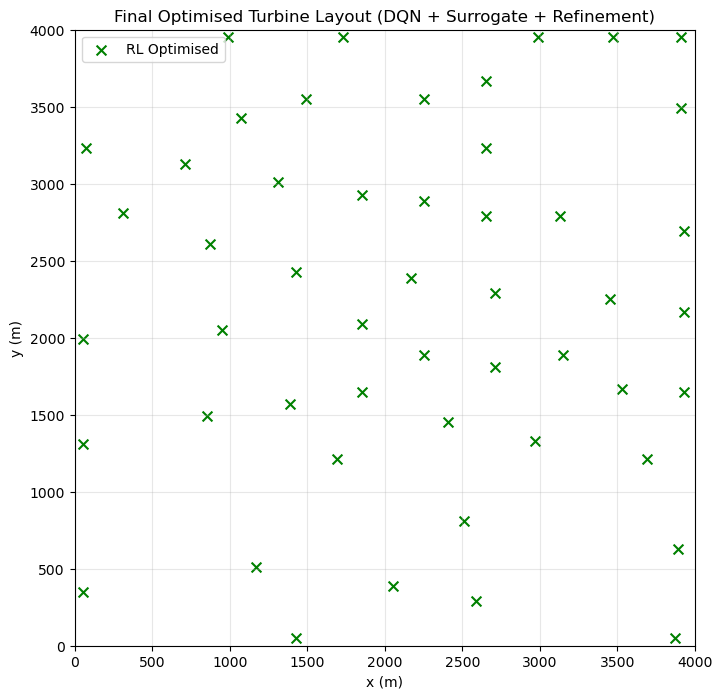

In [25]:
df_out = pd.DataFrame(refined_coords, columns=['x', 'y'])
df_out.to_csv('turbine_layout_rl_optimised.csv', index=False)

plt.figure(figsize=(8,8))
plt.scatter(refined_coords[:,0], refined_coords[:,1], c='green', marker='x', s=50, label='RL Optimised')
plt.xlim(0,4000)
plt.ylim(0,4000)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Final Optimised Turbine Layout (DQN + Surrogate + Refinement)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [11]:
refined_coords

array([[3130, 2790],
       [ 310, 2810],
       [1730, 3950],
       [1170,  510],
       [ 950, 2050],
       [  70, 3230],
       [2050,  390],
       [1690, 1210],
       [ 990, 3950],
       [2170, 2390],
       [  50, 1990],
       [2250, 3550],
       [  50, 1310],
       [1390, 1570],
       [2710, 2290],
       [2590,  290],
       [3870,   50],
       [1430,   50],
       [ 710, 3130],
       [2410, 1450],
       [1430, 2430],
       [3470, 3950],
       [1850, 2090],
       [1310, 3010],
       [3910, 3950],
       [2710, 1810],
       [2650, 2790],
       [1850, 2930],
       [2250, 1890],
       [3930, 2690],
       [3930, 2170],
       [2250, 2890],
       [  50,  350],
       [2510,  810],
       [3150, 1890],
       [3690, 1210],
       [3930, 1650],
       [3530, 1670],
       [ 850, 1490],
       [2650, 3670],
       [1070, 3430],
       [3450, 2250],
       [ 870, 2610],
       [2990, 3950],
       [2970, 1330],
       [1490, 3550],
       [2650, 3230],
       [1850,

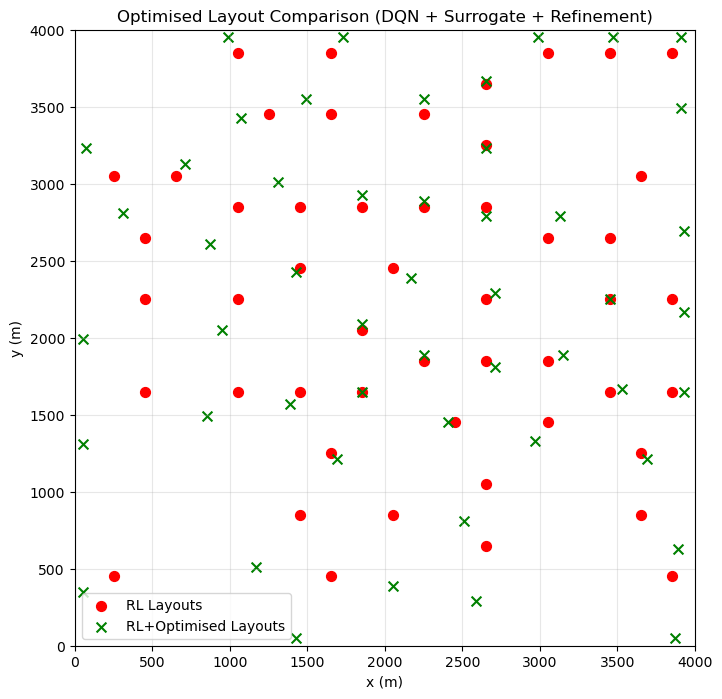

AEP produced by RL alone = 488.828369140625 GWh 
AEP produced by RL and refinement together = 519.6065673828125 GWh


In [34]:
df_out1 = pd.DataFrame(refined, columns=['x', 'y'])
df_out1.to_csv('turbine_layout_rl_optimised.csv', index=False)

plt.figure(figsize=(8,8))
plt.scatter(rl_layouts[0],rl_layouts[1], c='red', marker='o', s=50, label='RL Layouts')
plt.scatter(refined_coords[:,0], refined_coords[:,1], c='green', marker='x', s=50, label='RL+Optimised Layouts')
plt.xlim(0,4000)
plt.ylim(0,4000)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Optimised Layout Comparison (DQN + Surrogate + Refinement)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"AEP produced by RL alone = {true_aep_rl} GWh \nAEP produced by RL and refinement together = {aep_rl_refine} GWh")